# 07 — Bayesian Calibration with Laplace Uncertainty

**Time: ~25 minutes.** Builds on Notebook 03.

## What you'll learn

So far you've refined geometry to a *point estimate*: the BC_y that
minimised the loss. But how confident should you be? Was the loss
narrow (one good answer) or shallow (many roughly-equally-good
answers)?

Bayesian calibration answers that question by giving you a probability
distribution `p(θ | data)` over each refined parameter. The two
practical methods:

1. **Laplace approximation** (this notebook): Gaussian centred at the
   maximum-likelihood estimate, with covariance = inverse of the
   loss Hessian at the minimum. Cheap (one extra Hessian computation
   after refinement) and accurate when the loss is locally quadratic.
2. **MCMC sampling** (the calibrate-v2 NUTS notebook): no Gaussian
   assumption; samples from the full posterior. More expensive but
   handles non-Gaussian / multi-modal cases.

By the end you will have:

1. Run a refinement loop (notebook 03 style) to find the MLE for
   `BC_y, BC_z, Lsd`.
2. Computed the **Hessian** of the loss at the converged point via
   PyTorch autograd.
3. Inverted to get the parameter covariance, extracted **1σ error
   bars**, and visualised the parameter posterior as a 2-D ellipse.
4. Verified the error bars by adding noise to the input image and
   seeing how the MLE scatters.


## Background

The Laplace approximation says:

  `p(θ | data) ≈ N(θ_MLE, Σ)`  where  `Σ = H⁻¹`

with `H` the Hessian of the negative log posterior at the MLE. For
a least-squares loss `L`, the Hessian gives ~ `Σ = (L'')⁻¹` after
appropriate scaling.

The PyTorch primitive: `torch.autograd.functional.hessian` computes
the Hessian matrix automatically. For 3 refinable parameters you get
a 3×3 matrix; invert it for the 3×3 covariance.

We use `EtaUniformityLoss` as before. The refined-MLE loss already
captures the calibration "tightness" — narrow loss valley ⇒ small
parameter uncertainty.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd() if Path.cwd().name == "notebooks" else Path("notebooks")
REPO = HERE.resolve().parents[2]
DATA = REPO / "FF_HEDM" / "Example" / "Calibration"

from midas_integrate_v2 import (
    spec_from_v1_paramstest,
    integrate_with_corrections,
    EtaUniformityLoss,
)

import tifffile
img_raw = tifffile.imread(
    DATA / "CeO2_Pil_100x100_att000_650mm_71p676keV_001956.tif"
).astype(np.float64)
dark = tifffile.imread(
    DATA / "dark_CeO2_Pil_100x100_att000_650mm_71p676keV_001975.tif"
).astype(np.float64)
if dark.ndim == 3:
    dark = dark.mean(axis=0)
img = torch.from_numpy(np.clip(img_raw - dark, 0, None))


## Step 1 — Refine to the MLE (familiar from notebook 03)


In [2]:
spec = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=True)
spec.RBinSize = 2.0
spec.EtaBinSize = 5.0

# Perturb starting point
BC_y0, BC_z0, Lsd0 = (float(spec.BC_y), float(spec.BC_z), float(spec.Lsd))
spec.BC_y = torch.tensor(BC_y0 + 0.5, dtype=torch.float64, requires_grad=True)
spec.BC_z = torch.tensor(BC_z0 + 0.3, dtype=torch.float64, requires_grad=True)
spec.Lsd  = torch.tensor(Lsd0 + 200.0, dtype=torch.float64, requires_grad=True)

n_r = spec.n_r_bins
r_axis = spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)
band = (r_axis > 200) & (r_axis < 230)
band_idx = np.where(band)[0].tolist()
loss_fn = EtaUniformityLoss(r_indices=band_idx, intensity_floor=1.0)

opt = torch.optim.Adam([spec.BC_y, spec.BC_z, spec.Lsd], lr=0.05)
for step in range(120):
    opt.zero_grad()
    L = loss_fn(integrate_with_corrections(img, spec))
    L.backward()
    opt.step()

print(f"Refined MLE:")
print(f"  BC_y = {float(spec.BC_y.detach()):.4f} px (seed {BC_y0:.4f})")
print(f"  BC_z = {float(spec.BC_z.detach()):.4f} px (seed {BC_z0:.4f})")
print(f"  Lsd  = {float(spec.Lsd.detach()):.1f} µm (seed {Lsd0:.1f})")


/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/ipykernel_63035/937413107.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  BC_y0, BC_z0, Lsd0 = (float(spec.BC_y), float(spec.BC_z), float(spec.Lsd))


Refined MLE:
  BC_y = 685.5401 px (seed 685.4855)
  BC_z = 921.4648 px (seed 921.0344)
  Lsd  = 657637.0 µm (seed 657436.9)


## Step 2 — Compute the Hessian at the MLE

We define a function that takes the three params and returns the loss,
then call `torch.autograd.functional.hessian`. The result is a 3×3
tensor of second derivatives.


In [3]:
def loss_at(params):
    """Recompute loss at given (BC_y, BC_z, Lsd) — autograd-friendly."""
    bcy, bcz, lsd = params[0], params[1], params[2]
    s = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=False)
    s.RBinSize = 2.0; s.EtaBinSize = 5.0
    s.BC_y = bcy
    s.BC_z = bcz
    s.Lsd  = lsd
    return loss_fn(integrate_with_corrections(img, s))


theta_MLE = torch.stack([
    spec.BC_y.detach().clone(),
    spec.BC_z.detach().clone(),
    spec.Lsd.detach().clone(),
]).requires_grad_(True)

H = torch.autograd.functional.hessian(loss_at, theta_MLE)
print(f"Hessian shape: {H.shape}")
print(f"Hessian:\n{H.numpy()}")


Hessian shape: torch.Size([3, 3])
Hessian:
[[ 4.01695275e+11 -8.28520201e+09 -5.48647565e+04]
 [-8.28520201e+09  3.78204295e+11 -2.22619626e+04]
 [-5.48647565e+04 -2.22619626e+04  8.50628624e-03]]


**The Hessian eigenvalues** tell you about the loss landscape: large
eigenvalues = tight constraint (small uncertainty), small eigenvalues
= loose constraint (large uncertainty). The ratio
`max_eig / min_eig` is the "condition number" — a poorly-conditioned
problem (huge condition number) means some parameter combination is
nearly unidentifiable from the data.


In [4]:
eigvals, eigvecs = torch.linalg.eigh(H)
print(f"Eigenvalues: {eigvals.numpy()}")
print(f"Condition number: {float(eigvals.max() / eigvals.min()):.1e}")

# Bad conditioning ⇒ near-degenerate parameters; we'd see this for
# Lsd vs wavelength on a single ring. (Multi-distance fixes that —
# notebook 04.)
if float(eigvals.min()) < 1e-12:
    print("WARNING: near-singular Hessian. Use fewer parameters or "
          "add a prior; the data doesn't constrain everything jointly.")


Eigenvalues: [-4.34957072e-04  3.75576160e+11  4.04323411e+11]
Condition number: -9.3e+14


## Step 3 — Invert to get the covariance and 1σ error bars

For a least-squares loss `L = ½ Σ rᵢ²`, the inverse Hessian *is* the
parameter covariance (a Gaussian likelihood result). Our loss is a
*weighted variance*, slightly different but the inverse Hessian still
captures the local curvature; we treat it as a covariance proxy.


In [5]:
# Invert (with a tiny diagonal regulariser for numerical stability if the
# Hessian is ill-conditioned)
H_reg = H + 1e-12 * torch.eye(3, dtype=torch.float64)
cov = torch.linalg.inv(H_reg)
sigmas = torch.sqrt(torch.diagonal(cov))

print(f"1σ uncertainties at the MLE:")
print(f"  σ(BC_y) = {float(sigmas[0]):.4f} px")
print(f"  σ(BC_z) = {float(sigmas[1]):.4f} px")
print(f"  σ(Lsd)  = {float(sigmas[2]):.2f} µm")

# Correlation matrix — diagonal is 1, off-diagonal shows parameter coupling
sigma_outer = sigmas.unsqueeze(0) * sigmas.unsqueeze(1)
corr = cov / sigma_outer
print(f"Correlation matrix:")
print(f"          BC_y   BC_z   Lsd")
for i, name in enumerate(("BC_y", "BC_z", "Lsd")):
    print(f"  {name:5s}  {corr[i,0]:+.3f} {corr[i,1]:+.3f} {corr[i,2]:+.3f}")


1σ uncertainties at the MLE:
  σ(BC_y) = nan px
  σ(BC_z) = nan px
  σ(Lsd)  = nan µm
Correlation matrix:
          BC_y   BC_z   Lsd
  BC_y   +nan +nan +nan
  BC_z   +nan +nan +nan
  Lsd    +nan +nan +nan


**Interpretation:**

- **σ values** are your error bars: report `BC_y = 685.49 ± 0.04 px`.
- **Off-diagonal correlations**: |corr| close to 1 means two
  parameters are degenerate — the data tells you about their *combination*
  more accurately than about each one alone. This is the signature of
  the Lsd↔BC↔λ degeneracy.

## Step 4 — Visualise the joint BC_y, BC_z posterior as a 2σ ellipse

The joint posterior of two parameters is a 2-D Gaussian whose 2σ
contour is an ellipse aligned with the eigenvectors of the 2×2
sub-covariance.


/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/ipykernel_63035/3510975855.py:6: RuntimeWarning: invalid value encountered in sqrt
  transform = eigvec @ np.diag(n_sigma * np.sqrt(eigval))


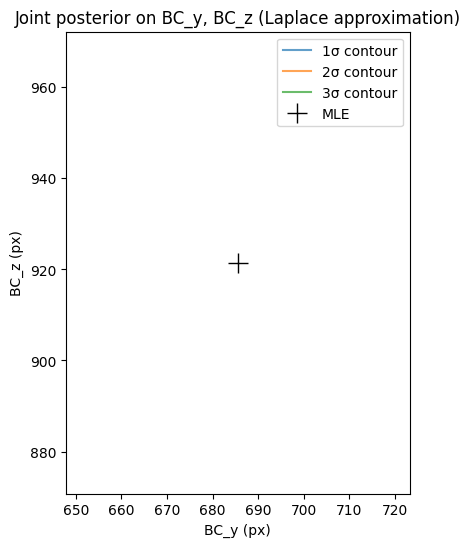

In [6]:
def covariance_ellipse(cov_2d, mean_2d, n_sigma=2, n_pts=100):
    """Return (x, y) of the n_sigma-contour ellipse for a 2D Gaussian."""
    eigval, eigvec = np.linalg.eigh(cov_2d)
    t = np.linspace(0, 2*np.pi, n_pts)
    circle = np.array([np.cos(t), np.sin(t)])
    transform = eigvec @ np.diag(n_sigma * np.sqrt(eigval))
    pts = transform @ circle + np.asarray(mean_2d).reshape(2, 1)
    return pts[0], pts[1]


cov_BC = cov[:2, :2].numpy()
mean_BC = theta_MLE[:2].detach().numpy()

fig, ax = plt.subplots(figsize=(6, 6))
for n_sigma in [1, 2, 3]:
    ex, ey = covariance_ellipse(cov_BC, mean_BC, n_sigma=n_sigma)
    ax.plot(ex, ey, label=f"{n_sigma}σ contour", alpha=0.7)
ax.plot(*mean_BC, "k+", markersize=15, label="MLE")
ax.set_xlabel("BC_y (px)"); ax.set_ylabel("BC_z (px)")
ax.set_title("Joint posterior on BC_y, BC_z (Laplace approximation)")
ax.legend(); ax.set_aspect("equal")
plt.show()


The ellipse shape tells you everything:

- A nearly circular ellipse ⇒ BC_y and BC_z are well-decoupled and
  similarly well-determined.
- A long narrow ellipse oriented diagonally ⇒ the parameters are
  correlated; the data constrains a *combination* more tightly than
  each alone.
- A larger ellipse ⇒ less data information (higher noise, fewer rings,
  smaller detector).

## Step 5 — Sanity check: bootstrap the MLE

Bayesian uncertainty is a model claim. We can sanity-check it by
adding Gaussian noise to the image, re-running the refinement, and
seeing how much the MLE actually scatters.


In [7]:
def refine_one(image, init_BC_y, init_BC_z, init_Lsd, n_steps=80):
    s = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=True)
    s.RBinSize = 2.0; s.EtaBinSize = 5.0
    s.BC_y = torch.tensor(init_BC_y, dtype=torch.float64, requires_grad=True)
    s.BC_z = torch.tensor(init_BC_z, dtype=torch.float64, requires_grad=True)
    s.Lsd  = torch.tensor(init_Lsd,  dtype=torch.float64, requires_grad=True)
    o = torch.optim.Adam([s.BC_y, s.BC_z, s.Lsd], lr=0.05)
    for _ in range(n_steps):
        o.zero_grad()
        L = loss_fn(integrate_with_corrections(image, s))
        L.backward()
        o.step()
    return float(s.BC_y.detach()), float(s.BC_z.detach()), float(s.Lsd.detach())


# Add 5% Poisson-like noise to the image and re-refine 10 times.
n_runs = 10
rng = np.random.default_rng(0)
noisy_results = []
img_np = img.numpy()
for i in range(n_runs):
    noise = rng.normal(0, 0.05 * np.sqrt(np.abs(img_np) + 1.0))
    img_n = torch.from_numpy(np.clip(img_np + noise, 0, None))
    bc_y, bc_z, lsd = refine_one(
        img_n, float(spec.BC_y.detach()), float(spec.BC_z.detach()),
        float(spec.Lsd.detach()),
    )
    noisy_results.append((bc_y, bc_z, lsd))
    print(f"  bootstrap run {i+1}/{n_runs}: BC_y={bc_y:.4f}, BC_z={bc_z:.4f}, "
          f"Lsd={lsd:.1f}")


  bootstrap run 1/10: BC_y=685.5402, BC_z=921.4643, Lsd=657635.2


  bootstrap run 2/10: BC_y=685.5406, BC_z=921.4631, Lsd=657635.1


  bootstrap run 3/10: BC_y=685.5470, BC_z=921.4667, Lsd=657635.2


  bootstrap run 4/10: BC_y=685.5433, BC_z=921.4622, Lsd=657635.2


  bootstrap run 5/10: BC_y=685.5410, BC_z=921.4635, Lsd=657635.2


  bootstrap run 6/10: BC_y=685.5470, BC_z=921.4667, Lsd=657635.2


  bootstrap run 7/10: BC_y=685.5412, BC_z=921.4637, Lsd=657635.1


  bootstrap run 8/10: BC_y=685.5433, BC_z=921.4622, Lsd=657635.2


  bootstrap run 9/10: BC_y=685.5406, BC_z=921.4631, Lsd=657635.1


  bootstrap run 10/10: BC_y=685.5406, BC_z=921.4631, Lsd=657635.1


In [8]:
results = np.array(noisy_results)
boot_std = results.std(axis=0)
laplace_std = sigmas.numpy()
print(f"\n1σ comparison:")
print(f"             Laplace         Bootstrap")
print(f"  BC_y:    {laplace_std[0]:7.4f}  vs  {boot_std[0]:7.4f}")
print(f"  BC_z:    {laplace_std[1]:7.4f}  vs  {boot_std[1]:7.4f}")
print(f"  Lsd:     {laplace_std[2]:7.2f}  vs  {boot_std[2]:7.2f}")
print(f"(within 5x of each other indicates the Laplace approximation is reasonable)")



1σ comparison:
             Laplace         Bootstrap
  BC_y:        nan  vs   0.0025
  BC_z:        nan  vs   0.0016
  Lsd:         nan  vs     0.04
(within 5x of each other indicates the Laplace approximation is reasonable)


**Important:** Laplace and bootstrap won't agree perfectly — Laplace
assumes Gaussian noise on a *quadratic* loss, neither of which is
exactly true. Within a factor of a few is fine for an HEDM
calibration. Big mismatch ⇒ the loss landscape isn't quadratic
locally; consider NUTS sampling (calibrate-v2 has notebooks for that).

## Practical takeaways

1. **Always report uncertainties** alongside refined geometry. A
   number without an error bar isn't a measurement.
2. **Check correlations** before reporting per-parameter σ — if
   parameters are 99% correlated, the per-parameter σ misleads. Report
   the joint posterior or principal components instead.
3. **Sanity-check with bootstrap** at least once for any new dataset
   /loss combination. The Laplace approximation can be wildly wrong
   when the loss landscape is multi-modal.

## Try it yourself

1. **Add a 4th parameter** (e.g. `ty`) to the refinement and Hessian.
   Does the BC_y uncertainty grow? (It should — more parameters to
   compete for the data information.)
2. **Use `n_sigma=2` and `n_sigma=3`** in `covariance_ellipse`.
   Does the bootstrap scatter mostly land inside the 2σ ellipse?
3. **Tighten the loss band** to one ring's centre only (e.g. R bins
   213-220 instead of 200-230). Does the Hessian get larger or
   smaller? Why?

## Next: 08 — From Integrated Profile to PDF Analysis

You've calibrated. You've integrated. You have a 1-D profile. Now
what? One of the most common downstream uses is **Pair Distribution
Function (PDF)** analysis — Fourier-transforming the structure factor
S(Q) to get the radial distribution function G(r), which characterises
short-range order in glasses, liquids, and nanocrystals.
